<h2>NSL-KDD & CICIDS2017 Attack Data Visualization</h2>

This notebook explores the **distribution of attacks vs normal traffic** in the NSL-KDD and CICIDS2017 datasets. 
We create both multi-class and binary classification visualizations.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


<h2>NSL-KDD Dataset</h2>

We first load the NSL-KDD dataset, inspect its structure, and create a **binary column** for Normal vs Attack traffic.


In [4]:
# Load NSL-KDD dataset
df = pd.read_csv("../data/KDDTrain+.txt", header=None)


# Rename columns
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'
]
df.columns = columns

# Map outcome to categories
attack_mapping = {
    'neptune': 'DoS', 'smurf': 'DoS', 'back': 'DoS', 'teardrop': 'DoS', 'pod': 'DoS',
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe',
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L',
    'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'rootkit': 'U2R', 'perl': 'U2R',
    'normal': 'Normal'
}
df['category'] = df['outcome'].map(attack_mapping).fillna('Other')

# Create binary column
df['binary'] = df['category'].apply(lambda x: 'Normal' if x=='Normal' else 'Attack')


<h2>Binary Classification: Normal vs Attack</h2>

Visualizing the **distribution of normal vs attack traffic** in the NSL-KDD dataset.


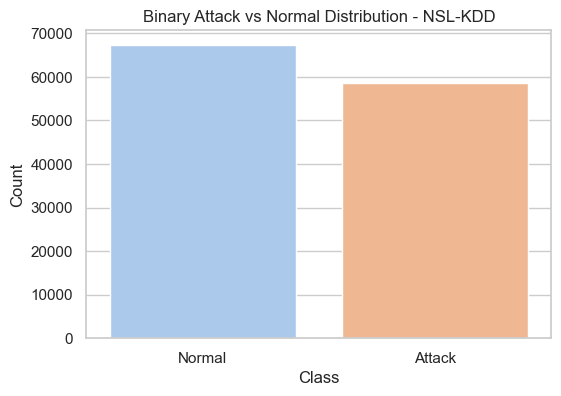

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='binary', data=df, palette='pastel', hue='binary', legend=False)
plt.title('Binary Attack vs Normal Distribution - NSL-KDD')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


<h2>Multi-Class Attack Distribution</h2>

Visualizing the distribution of the **top 10 attack categories** in NSL-KDD.


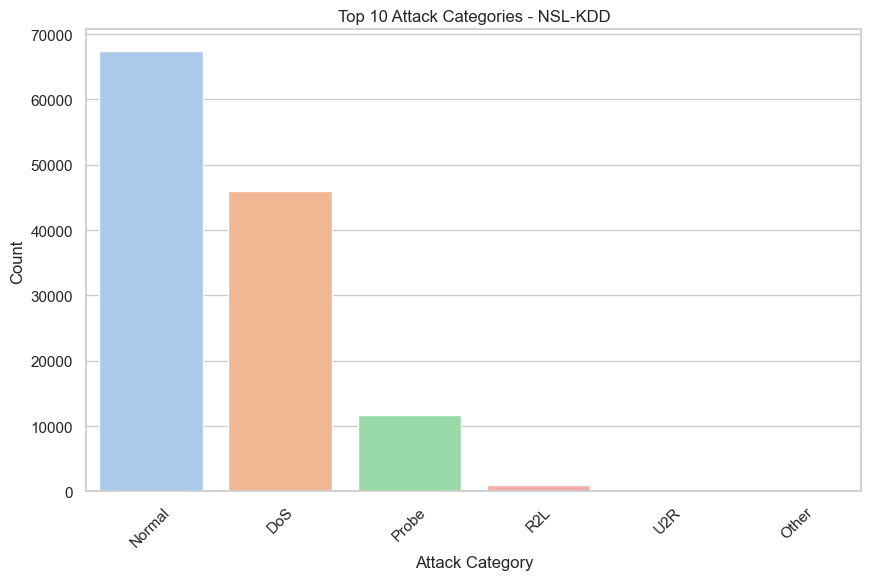

In [6]:
top_attacks = df['category'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_attacks.index, y=top_attacks.values, hue=top_attacks.index, dodge=False, palette='pastel', legend=False)
plt.title('Top 10 Attack Categories - NSL-KDD')
plt.xlabel('Attack Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

